# 🎮💹 NOTEBOOK DE VELJKO L'ANALYSTE (et pro gamer)	🎮💹

## === GUIDE des fonctions du module local datalake === 

from DATALAKE.data import *

**data = data_download_gmd("country")** -> Telechargement des données liés à un pays via global_macro_dataset (BD publique)
**data = data_download_fred("indicator"** : str, "start" : str , "end" : str) -> Telechargement d'un indicateur via la FRED (BD publique)

**data_storing(data : dataframe, "nom_fichier" : str)** -> Range un dataframe "data" dans le DATALAKE en parquet, que vous venez de télécharger d'internet 

**data = import_parquet("file_name" : str)** -> importe un dataframe du DATALAKE dans votre file cible (notebook ou .py)

**which_parquet()** -> Vous renvoie une liste de l'ensemble des parquets dispo dans le 

## === Pour importer les fonctions du fichier "outils_eda", si vous en avez besoin lors de votre analyse ===

import sys
import os

sys.path.append("../dorian_code") -> permet à Python d'aller lire les fichiers présent dans le dossier "dorian_code"

from outils_eda import * -> importe le fichier "outils_eda" dont ces fonctions que vous pouvez utiliser lors de l'analyse !

Important des différents package

In [148]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

In [149]:
# 1. Définition du chemin d'accès au fichier (le 'r' devant sert à ignorer les antislashs Windows)
path_parquet_file = r"C:\Users\veljk\economic_research\DATALAKE\PARQUET_FOLDER\main_detrended.parquet"

# 2. Chargement du fichier Parquet dans un DataFrame Pandas
df = pd.read_parquet(path_parquet_file)

# 3. Création d'un nouveau DataFrame en sélectionnant uniquement les colonnes nécessaires à l'analyse
# On utilise .copy() pour s'assurer que 'df_detrended' est indépendant du DataFrame original
df_detrended = df[[
    'year',                  # L'axe temporel
    'gdp_nominal_stat',      # PIB nominal stationnarisé
    'expected_inflation',    # Inflation anticipée
    'taux_changes_stat',     # Taux de change (stationnaire)
    'cpi_stat',              # Indice des prix à la consommation (stationnaire)
    'taux_directeur',        # Taux d'intérêt de la banque centrale
    'export_stat',           # Exportations (stationnaire)
    'import_stat_stat',      # Importations (stationnaire)
    'yield_perpetual_stat',  # Rendement perpétuel (stationnaire)
    'oil_price_stat',        # Prix du pétrole (stationnaire)
    'gdp_cycle',             # Composante cyclique du PIB
    'gdp_trend_stat_stat',   # Tendance du PIB (stationnaire)
    'output_gap'             # Écart de production (indicateur de surchauffe/récession)
]].copy()

In [150]:
# 1. Régime "Gold Standard" : on marque d'un '1' toutes les années jusqu'à 1932 inclus
df_detrended['d_gold'] = np.where(df_detrended['year'] <= 1932, 1, 0)

# 2. Régime "Bretton Woods" : on marque d'un '1' l'intervalle 1944-1971
# Note l'usage du '&' pour combiner les deux bornes temporelles
df_detrended['d_woods'] = np.where((df_detrended['year'] >= 1944) & (df_detrended['year'] <= 1971), 1, 0)

# 3. Régime "Floating" (Changes flottants) : on marque d'un '1' tout ce qui suit 1971
df_detrended['d_floating'] = np.where(df_detrended['year'] >= 1972, 1, 0)

In [151]:
# --- CRÉATION DES VARIABLES D'INTERACTION (EFFICACITÉ PAR RÉGIME) ---

# On multiplie le taux directeur par la dummy 'Gold Standard'
# Résultat : la valeur du taux si year <= 1932, sinon 0.
df_detrended['gold_int'] = df_detrended['taux_directeur'] * df_detrended['d_gold']

# On multiplie le taux directeur par la dummy 'Bretton Woods'
# Résultat : la valeur du taux uniquement entre 1944 et 1971, sinon 0.
df_detrended['woods_int'] = df_detrended['taux_directeur'] * df_detrended['d_woods']

# On multiplie le taux directeur par la dummy 'Floating'
# Résultat : la valeur du taux uniquement pour la période après 1971, sinon 0.
df_detrended['floating_int'] = df_detrended['taux_directeur'] * df_detrended['d_floating']


In [152]:
# 1. Définition des variables cibles (Y)
# On prépare les trois dimensions de l'économie britannique
Y_gdp = df_detrended['gdp_nominal_stat']       # Croissance (PIB)
Y_inflation = df_detrended['cpi_stat']         # Stabilité des prix (Inflation)
Y_change = df_detrended['taux_changes_stat']   # Valeur externe (Taux de change)

# 2. Définition de la matrice des variables explicatives (X)
# On utilise nos 3 interactions pour capturer l'effet du taux par régime
X = df_detrended[['gold_int', 'woods_int', 'floating_int']]

# 3. Ajout de la constante (Intercepte)
# Indispensable pour ne pas biaiser les coefficients des régimes
X = sm.add_constant(X)

# 4. Estimation des trois modèles (OLS)
# On utilise 'missing=drop' pour gérer les trous historiques (ex: guerres mondiales)
model_gdp_1 = sm.OLS(Y_gdp, X, missing='drop').fit()
model_inf_1 = sm.OLS(Y_inflation, X, missing='drop').fit()
model_exch_1= sm.OLS(Y_change, X, missing='drop').fit()

# 5. Affichage des résultats avec séparateurs
print(model_gdp_1.summary())
print(model_inf_1.summary())
print(model_exch_1.summary())

                            OLS Regression Results                            
Dep. Variable:       gdp_nominal_stat   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.419
Method:                 Least Squares   F-statistic:                     26.02
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           1.49e-12
Time:                        17:39:14   Log-Likelihood:                 217.21
No. Observations:                 105   AIC:                            -426.4
Df Residuals:                     101   BIC:                            -415.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0373      0.006      5.864   

In [153]:
# --- ÉTAPE 4 : MODÈLE AVEC VARIABLES DE CONTRÔLE ---

# Sélection des variables explicatives (X) et des contrôles (C)
# On regroupe les interactions par régime et les facteurs externes
C = df_detrended[[
    'gold_int', 'woods_int', 'floating_int', # Interactions (notre intérêt principal)
    'export_stat', 'import_stat_stat',       # Secteur extérieur
    'yield_perpetual_stat',                  # Taux longs (marché obligataire)
    'oil_price_stat',                        # Choc d'offre (Pétrole)
    'gdp_cycle', 'gdp_trend_stat_stat',      # Composantes du PIB
    'output_gap',                            # Écart de production (mesure de surchauffe)
    'expected_inflation'                     # Anticipations des agents
]]

# Ajout de la constante pour l'intercepte de la régression
C = sm.add_constant(C)

# Estimation des modèles OLS pour chaque variable cible
# On observe l'impact "toutes choses égales par ailleurs"
model_gdp_2 = sm.OLS(Y_gdp, C, missing='drop').fit()
model_inf_2 = sm.OLS(Y_inflation, C, missing='drop').fit()
model_exch_2 = sm.OLS(Y_change, C, missing='drop').fit()

# Affichage du résumé pour les taux de change
print(model_gdp_2.summary())

                            OLS Regression Results                            
Dep. Variable:       gdp_nominal_stat   R-squared:                       0.735
Model:                            OLS   Adj. R-squared:                  0.704
Method:                 Least Squares   F-statistic:                     23.48
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           2.98e-22
Time:                        17:39:14   Log-Likelihood:                 256.91
No. Observations:                 105   AIC:                            -489.8
Df Residuals:                      93   BIC:                            -458.0
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0228 

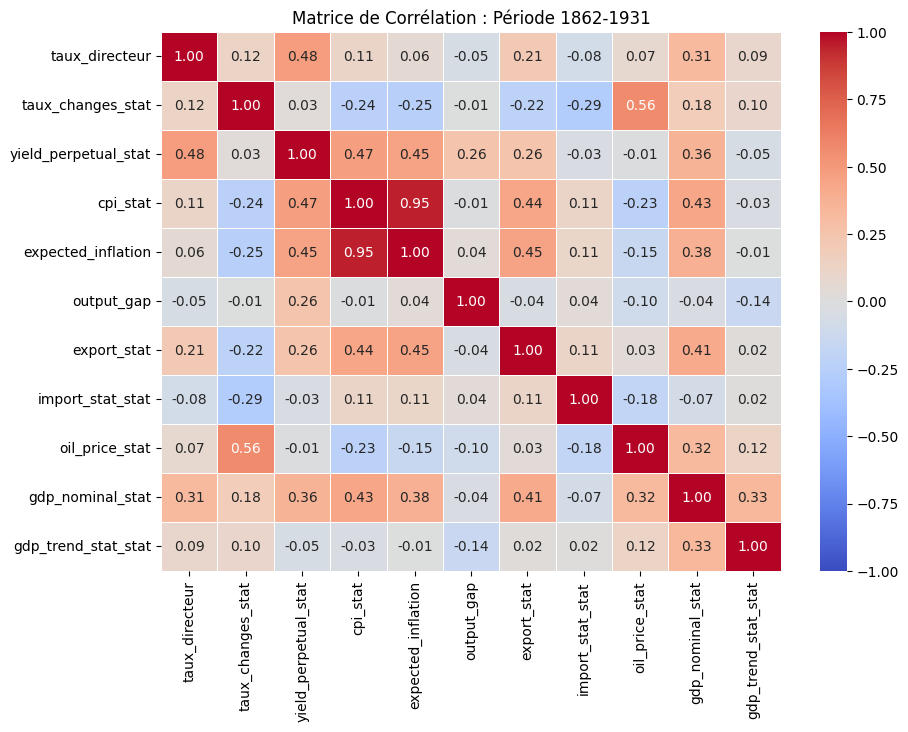

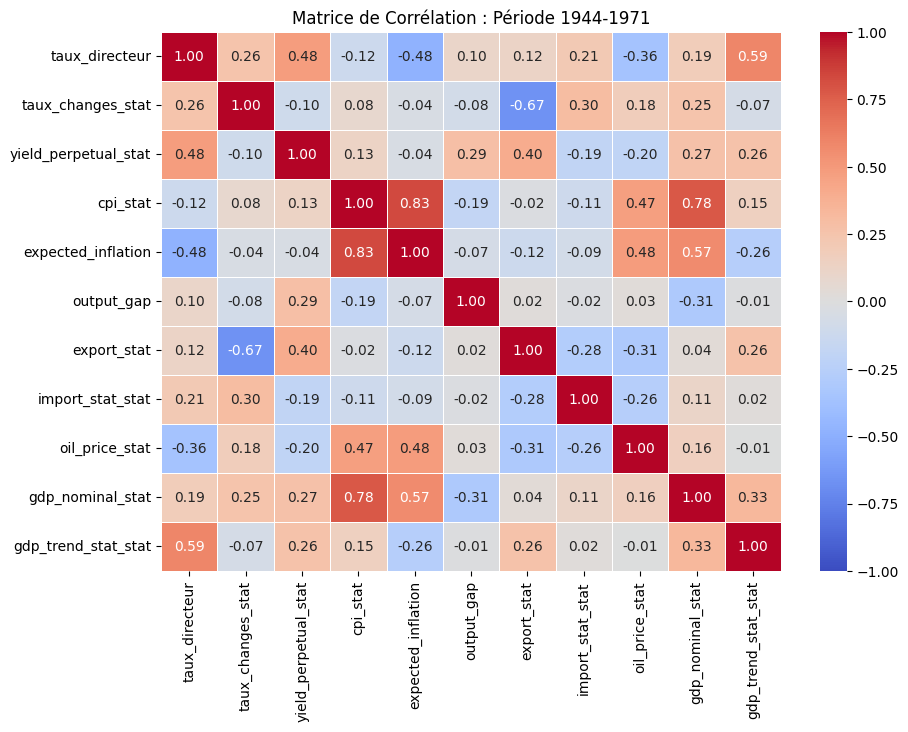

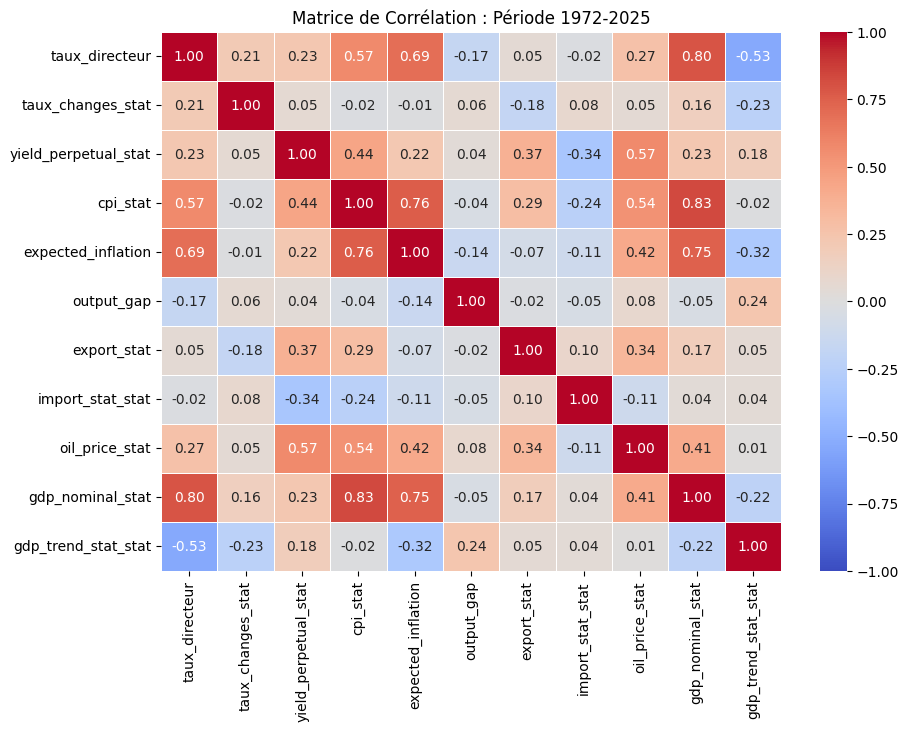

In [154]:
import sys
import os

sys.path.append("../dorian_code")

from outils_eda import *

cols_selection = ['year',
    'taux_directeur', 
    'taux_changes_stat', 
    'yield_perpetual_stat', 
    'cpi_stat', 
    'expected_inflation',
    'output_gap',
    'export_stat',
    'import_stat_stat', 
    'oil_price_stat', 
    'gdp_nominal_stat', 
    'gdp_trend_stat_stat'
]

corr_matrix(df_detrended[cols_selection])

In [ ]:
#---La variable expected_inflation a été retirée car très corrélée et output_gap et gpd_trend_stat_stat trop peu corrélé---
C2 = df_detrended[[
    'gold_int', 'woods_int', 'floating_int', # Interactions (notre intérêt principal)
    'export_stat', 'import_stat_stat',       # Secteur extérieur
    'yield_perpetual_stat',                  # Taux longs (marché obligataire)
    'oil_price_stat',                        # Choc d'offre (Pétrole)
    'output_gap',                            # Écart de production (mesure de surchauffe)                 
]]

# Ajout de la constante pour l'intercepte de la régression
C2 = sm.add_constant(C2)

# Estimation des modèles OLS pour chaque variable cible
# On observe l'impact "toutes choses égales par ailleurs"
model_gdp_3 = sm.OLS(Y_gdp, C2, missing='drop').fit()
model_inf_3 = sm.OLS(Y_inflation, C2, missing='drop').fit()
model_exch_3 = sm.OLS(Y_change, C2, missing='drop').fit()

# Affichage du résumé pour les taux de change
print(model_gdp_3.summary())

                            OLS Regression Results                            
Dep. Variable:       gdp_nominal_stat   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     11.57
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           2.21e-11
Time:                        17:39:16   Log-Likelihood:                 222.59
No. Observations:                 105   AIC:                            -427.2
Df Residuals:                      96   BIC:                            -403.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0388 

In [ ]:
#--Erreurs robustes à l'hétéroscédasticité, je comptes faire un plot avec les erreurs--
model_robust_gdp = sm.OLS(Y_gdp, C2, missing='drop').fit(cov_type='HC1')

print(model_robust_gdp.summary())

                            OLS Regression Results                            
Dep. Variable:       gdp_nominal_stat   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     16.41
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           4.57e-15
Time:                        17:39:16   Log-Likelihood:                 222.59
No. Observations:                 105   AIC:                            -427.2
Df Residuals:                      96   BIC:                            -403.3
Df Model:                           8                                         
Covariance Type:                  HC1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.0388 